# Text Embeddings Analysis for GRPO Results

This notebook analyzes text embeddings of code responses from GRPO training runs. We'll:
1. Load and preprocess the rollout data
2. Calculate passrates and select representative questions
3. Compute embeddings using sentence transformers
4. Perform dimensionality reduction (PCA, UMAP, t-SNE)
5. Visualize and analyze embedding patterns based on rewards

**Note**: We'll handle the torch/sentence-transformers dependency issue by using alternative approaches if needed.

**Another Note**: These rollouts are collected from a batch of trained models which were run with GRPO-groupsize 1, which means
we're basically running REINFORCE. Nontheless, we may look at the results and repeat the experiment later with a better rollout collection.

In [1]:
# Setup and Data Loading
import os
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Configuration
RECOMPUTE = False
TARGET_SAMPLES_PER_QUESTION = 100  # Number of samples per question for embedding analysis
TARGET_QUESTIONS = 30  # Number of questions to select consistently across all variants

# Set up paths
ROLLOUTS_DIR = "/u/rfechner/verl/workspace/rollouts/results"
EMBEDDINGS_DIR = "/u/rfechner/verl/workspace/plots/embeddings_data"
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

# Define datasets of interest
DATASETS = ['math500', 'aime25', 'minervamath', 'olympiadbench']
ENTROPY_VARIANTS = ['base', 'entropy0.0', 'entropy0.01']

print("Basic imports successful!")
print(f"Rollouts directory: {ROLLOUTS_DIR}")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Recompute flag: {RECOMPUTE}")
print(f"Target questions per dataset: {TARGET_QUESTIONS}")
print(f"Available datasets: {DATASETS}")
print(f"Entropy variants: {ENTROPY_VARIANTS}")

Basic imports successful!
Rollouts directory: /u/rfechner/verl/workspace/rollouts/results
Embeddings directory: /u/rfechner/verl/workspace/plots/embeddings_data
Recompute flag: False
Target questions per dataset: 30
Available datasets: ['math500', 'aime25', 'minervamath', 'olympiadbench']
Entropy variants: ['base', 'entropy0.0', 'entropy0.01']


In [2]:
def load_dataset(dataset_name, entropy_variant, rollouts_dir):
    """Load a specific dataset and entropy variant."""
    filename = f"{dataset_name}_{entropy_variant}.parquet"
    filepath = Path(rollouts_dir) / filename
    
    if filepath.exists():
        try:
            df = pd.read_parquet(filepath)
            df['dataset'] = dataset_name
            df['entropy_variant'] = entropy_variant
            df['source_file'] = filename
            print(f"Loaded {filename}: {len(df)} rows")
            return df
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return pd.DataFrame()
    else:
        print(f"File not found: {filename}")
        return pd.DataFrame()

def load_all_datasets(rollouts_dir, datasets=None, entropy_variants=None):
    """Load all specified datasets and variants."""
    if datasets is None:
        datasets = DATASETS
    if entropy_variants is None:
        entropy_variants = ENTROPY_VARIANTS
    
    all_data = {}
    
    for dataset in datasets:
        dataset_data = {}
        for variant in entropy_variants:
            df = load_dataset(dataset, variant, rollouts_dir)
            df.sort_index(inplace=True)
            if not df.empty:
                dataset_data[variant] = df
        
        if dataset_data:
            all_data[dataset] = dataset_data
            
    return all_data

# Load all datasets
print("Loading datasets...")
if RECOMPUTE:
    all_datasets = load_all_datasets(ROLLOUTS_DIR)
else:
    print("Recompute flag is False - will load from saved files when available")
    all_datasets = {}

Loading datasets...
Recompute flag is False - will load from saved files when available


## Passrate Calculation and Question Selection

Calculate passrates (average rewards) for each question and select questions with different difficulty levels.

In [3]:
def process_dataset(df, dataset_name, variant_name):
    """Process a single dataset variant for embedding analysis."""
    print(f"Processing {dataset_name} - {variant_name}")
    
    # Calculate passrates
    passrates = []
    for idx, row in df.iterrows():
        prompt = row['prompt']
        rewards = row['rewards']
        
        if isinstance(rewards, (list, np.ndarray)):
            passrate = np.mean(rewards)
        else:
            passrate = rewards
            
        passrates.append({
            'idx': idx,
            'prompt': prompt,
            'passrate': passrate,
            'num_responses': len(row['responses']) if isinstance(row['responses'], list) else 1,
            'responses': row['responses'],
            'rewards': rewards,
            'dataset': dataset_name,
            'variant': variant_name,
            'answer': row.get('answer', ''),  # Include correct answer if available
            'data_source': row.get('data_source', ''),
            'ability': row.get('ability', '')
        })
    
    passrates_df = pd.DataFrame(passrates)
    
    return passrates_df

# Set random seed for reproducibility
np.random.seed(42)

# Process datasets with simple random question selection
if RECOMPUTE and all_datasets:
    processed_datasets = {}
    
    for dataset_name, variants in all_datasets.items():
        processed_datasets[dataset_name] = {}
        # Get the first variant to select questions from
        first_variant = list(variants.keys())[0]
        first_df = variants[first_variant]
        questions_idxs = np.random.choice(a=len(first_df), size=TARGET_QUESTIONS, replace=False)
        
        # Process all variants using the same question indices
        for variant_name, df in variants.items():
            # Process this variant
            passrates_df = process_dataset(df, dataset_name, variant_name)
            
            # Filter to same questions
            variant_selected = passrates_df.iloc[questions_idxs].copy().sort_values(by='idx').reset_index(drop=True)
            
            processed_datasets[dataset_name][variant_name] = {
                'passrates_df': passrates_df,
                'selected_questions': variant_selected
            }
                
    print(f"\nProcessed {len(processed_datasets)} datasets with consistent question selection")
else:
    print("No datasets to process")

No datasets to process


## Response Sampling and Dataset Creation

Sample responses proportionally to maintain reward distribution and create the final dataset for embedding computation.

In [4]:
def create_embedding_dataset_simple(selected_questions):
    """Create dataset for embedding analysis - keep it simple, use all responses."""
    embedding_data = []
    
    for q_idx, row in selected_questions.iterrows():
        prompt = row['prompt']
        responses = row['responses']
        rewards = row['rewards']
        passrate = row['passrate']
        dataset = row['dataset']
        variant = row['variant']
        correct_answer = row['answer']
        
        # Use all responses without sampling
        for r_idx, (response, reward) in enumerate(zip(responses, rewards)):
            embedding_data.append({
                'dataset': dataset,
                'variant': variant,
                'question_idx': row['idx'],
                'question_id': f"{dataset}_{variant}_q{q_idx}",
                'response_id': f"{dataset}_{variant}_q{q_idx}_r{r_idx}",
                'prompt': prompt,
                'response': response,
                'correct_answer': correct_answer,
                'reward': reward,
                'passrate': passrate,
                'is_correct': reward == 1.0
            })
    
    return pd.DataFrame(embedding_data)

In [5]:
# Create embedding datasets for all processed datasets
embedding_datasets = {}

if RECOMPUTE and processed_datasets:
    for dataset_name, variants in processed_datasets.items():
        embedding_datasets[dataset_name] = {}
        
        for variant_name, data in variants.items():
            # Use the simplified function
            embedding_df = create_embedding_dataset_simple(data['selected_questions'])            
            embedding_datasets[dataset_name][variant_name] = embedding_df
            
    print(f"\nCreated embedding datasets for {len(embedding_datasets)} datasets")
else:
    print("No embedding datasets created")

No embedding datasets created


## Computing Text Embeddings

We'll try to use sentence transformers, but handle potential dependency issues gracefully by falling back to simpler approaches.

In [6]:
from sentence_transformers import SentenceTransformer

In [7]:
def compute_embeddings_for_dataset(embedding_df, dataset_name, variant_name):
    """Compute embeddings for a specific dataset."""
    print(f"Computing embeddings for {dataset_name} - {variant_name}")
    texts = embedding_df['response'].tolist()
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(texts, batch_size=512, show_progress_bar=True)
    return embeddings

def save_dataset_embeddings(dataset_name, variant_name, embedding_df, embeddings):
    """Save embeddings for a dataset."""
    save_path = os.path.join(EMBEDDINGS_DIR, f"{dataset_name}_{variant_name}_embeddings.pkl")
    
    data_to_save = {
        'dataset_name': dataset_name,
        'variant_name': variant_name,
        'embedding_df': embedding_df,
        'embeddings': embeddings,
        'timestamp': pd.Timestamp.now()
    }
    
    with open(save_path, 'wb') as f:
        pickle.dump(data_to_save, f)
    print(f"  Saved to: {save_path}")

def load_dataset_embeddings(dataset_name, variant_name):
    """Load embeddings for a dataset."""
    load_path = os.path.join(EMBEDDINGS_DIR, f"{dataset_name}_{variant_name}_embeddings.pkl")
    
    if os.path.exists(load_path):
        with open(load_path, 'rb') as f:
            data = pickle.load(f)
        print(f"Loaded embeddings for {dataset_name} - {variant_name}")
        return data['embedding_df'], data['embeddings']
    else:
        raise OSError(f"Coudn't find pickle file: {load_path}")

# Compute or load embeddings for all datasets
final_embeddings = {}
subset_datasets = ['math500']

for dataset_name in subset_datasets:
    final_embeddings[dataset_name] = {}
    
    for variant_name in ENTROPY_VARIANTS:
        print(f"\n=== Processing {dataset_name} - {variant_name} ===")
        
        if RECOMPUTE:
            # Compute new embeddings
            if (dataset_name in embedding_datasets and 
                variant_name in embedding_datasets[dataset_name]):
                
                embedding_df = embedding_datasets[dataset_name][variant_name]
                embeddings = compute_embeddings_for_dataset(
                    embedding_df, dataset_name, variant_name
                )
                
                # Save the results
                save_dataset_embeddings(dataset_name, variant_name, 
                                       embedding_df, embeddings)
                
                final_embeddings[dataset_name][variant_name] = {
                    'embedding_df': embedding_df,
                    'embeddings': embeddings,
                }
            else:
                print(f"  No data available for {dataset_name} - {variant_name}")
        else:
            # Try to load existing embeddings
            embedding_df, embeddings = load_dataset_embeddings(dataset_name, variant_name)
            
            if embedding_df is not None:
                final_embeddings[dataset_name][variant_name] = {
                    'embedding_df': embedding_df,
                    'embeddings': embeddings
                }
            else:
                print(f"  No saved embeddings found for {dataset_name} - {variant_name}")

print(f"\nFinal embeddings summary:")
for dataset_name, variants in final_embeddings.items():
    if variants:
        print(f"{dataset_name}: {list(variants.keys())}")
    else:
        print(f"{dataset_name}: No variants available")


=== Processing math500 - base ===
Loaded embeddings for math500 - base

=== Processing math500 - entropy0.0 ===
Loaded embeddings for math500 - entropy0.0

=== Processing math500 - entropy0.01 ===
Loaded embeddings for math500 - entropy0.01

Final embeddings summary:
math500: ['base', 'entropy0.0', 'entropy0.01']


## Dimensionality Reduction with PCA

Apply Principal Component Analysis to reduce embedding dimensions and create 2D scatter plots colored by reward values.

In [8]:
from sklearn.decomposition import PCA

# Focus on math500 dataset for detailed intra-question analysis
dataset_focus = 'math500'
variant_focus = 'base'  # Start with base variant


def plot_pca(dataset_focus, variant_focus):
    if (dataset_focus in final_embeddings and 
        variant_focus in final_embeddings[dataset_focus]):
        
        data = final_embeddings[dataset_focus][variant_focus]
        embedding_df = data['embedding_df']
        embeddings = data['embeddings']
        
        # Get unique questions
        unique_questions = embedding_df['question_id'].unique()
        
        # Apply PCA to all embeddings
        pca = PCA(n_components=2, random_state=42)
        embeddings_2d = pca.fit_transform(embeddings)
        
        print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
        
        # Create intra-question scatterplots
        n_questions = min(TARGET_QUESTIONS, len(unique_questions))
        questions_to_plot = unique_questions[:n_questions]
        
        # Set up the plot grid - use more columns for more questions
        cols = 5  # Increased from 3 to accommodate more questions
        rows = (n_questions + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        for i, question_id in enumerate(questions_to_plot):
            row = i // cols
            col = i % cols
            ax = axes[row, col]
            
            # Get data for this question
            question_mask = embedding_df['question_id'] == question_id
            question_data = embedding_df[question_mask]
            question_embeddings = embeddings_2d[question_mask]
            
            # Color by reward
            colors = ['red' if r == 1.0 else 'blue' for r in question_data['reward']]
            
            # Create scatter plot
            ax.scatter(question_embeddings[:, 0], question_embeddings[:, 1], 
                    c=colors, alpha=0.7, s=30)
            
            # Customize plot with just question ID and passrate
            question_info = question_data.iloc[0]
            passrate = question_info['passrate']
            
            ax.set_title(f"{question_id}\nPassrate: {passrate:.3f}", fontsize=10)
            ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
            ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
            ax.grid(True, alpha=0.3)
            
            # Add legend for first plot
            if i == 0:
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor='red', label='Correct (Reward=1)'),
                                Patch(facecolor='blue', label='Incorrect (Reward=0)')]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
            
            # Add statistics text
            n_correct = sum(question_data['reward'] == 1.0)
            n_total = len(question_data)
            stats_text = f"{n_correct}/{n_total} correct"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Hide empty subplots
        for i in range(n_questions, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].set_visible(False)
        
        plt.suptitle(f'{dataset_focus.upper()} - {variant_focus}: Intra-Question Embedding Analysis\n'
                    f'PCA 2D Projection (Explained Variance: {pca.explained_variance_ratio_.sum():.3f})', 
                    fontsize=16, y=0.98)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

    else:
        print(f"No data available for {dataset_focus} - {variant_focus}")
        print("Available combinations:")
        for dataset_name, variants in final_embeddings.items():
            for variant_name in variants.keys():
                print(f"  {dataset_name} - {variant_name}")

PCA explained variance: 0.175


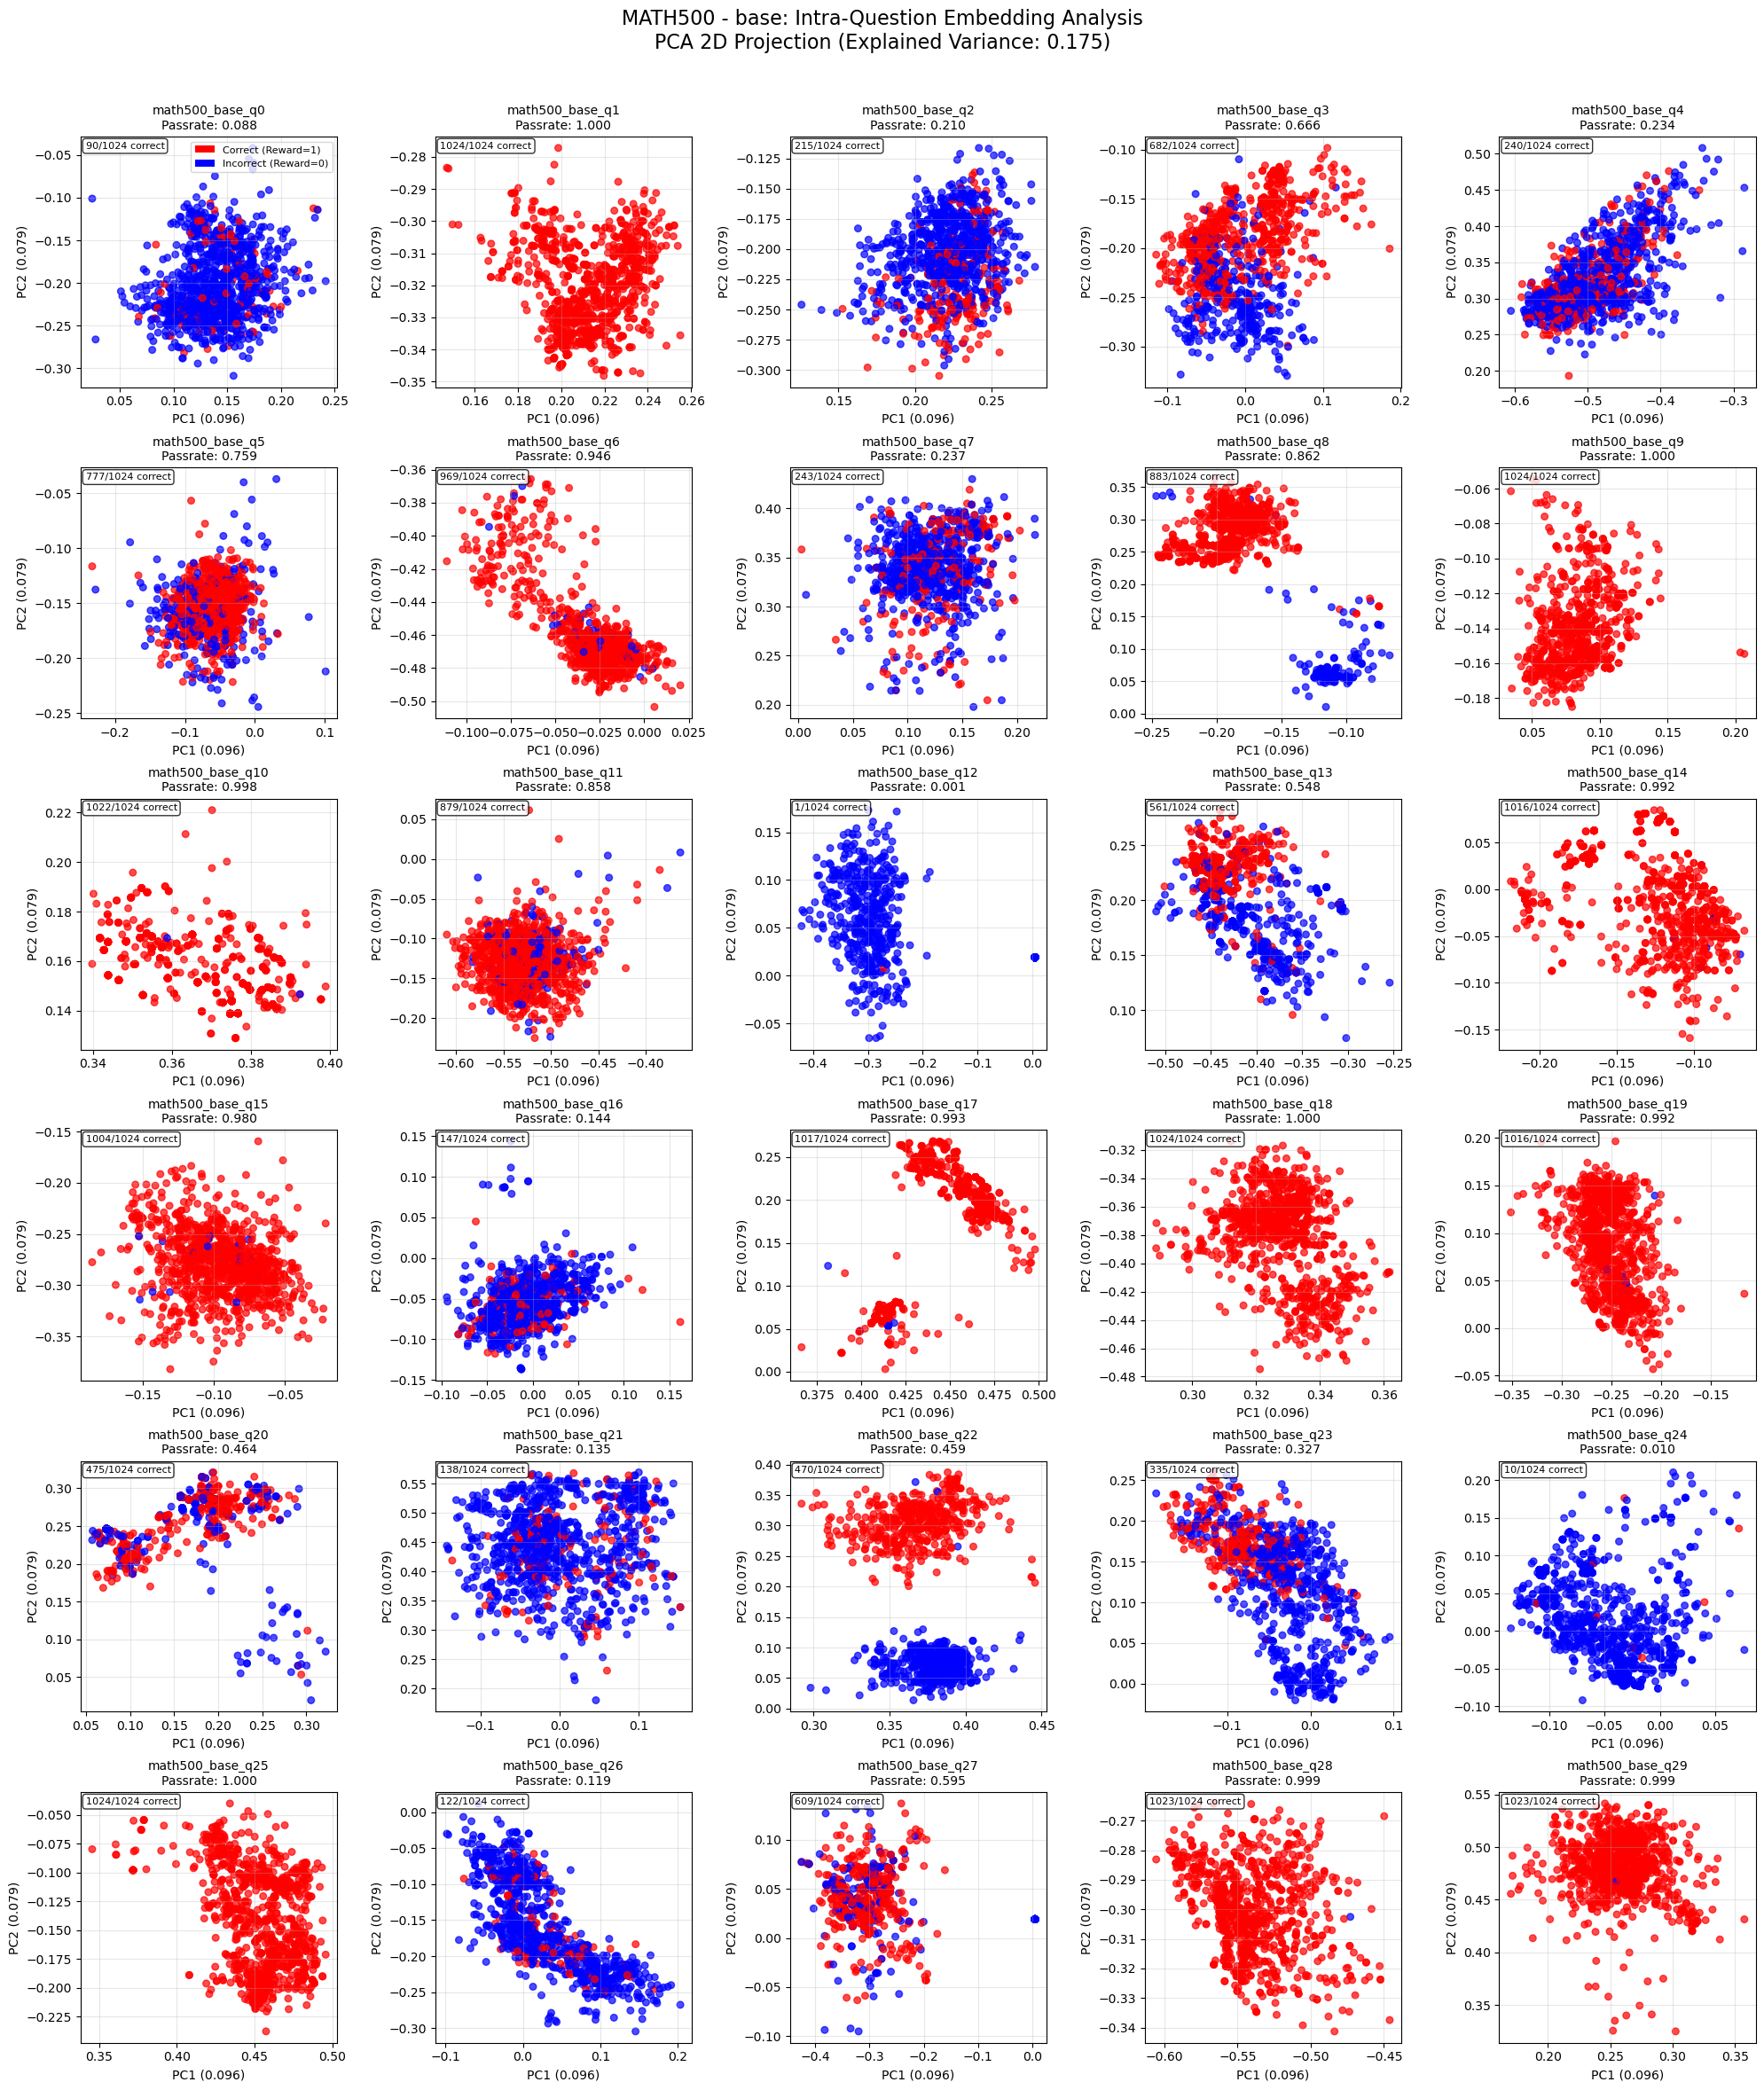

In [9]:
plot_pca(dataset_focus=dataset_focus, variant_focus=variant_focus)

PCA explained variance: 0.183


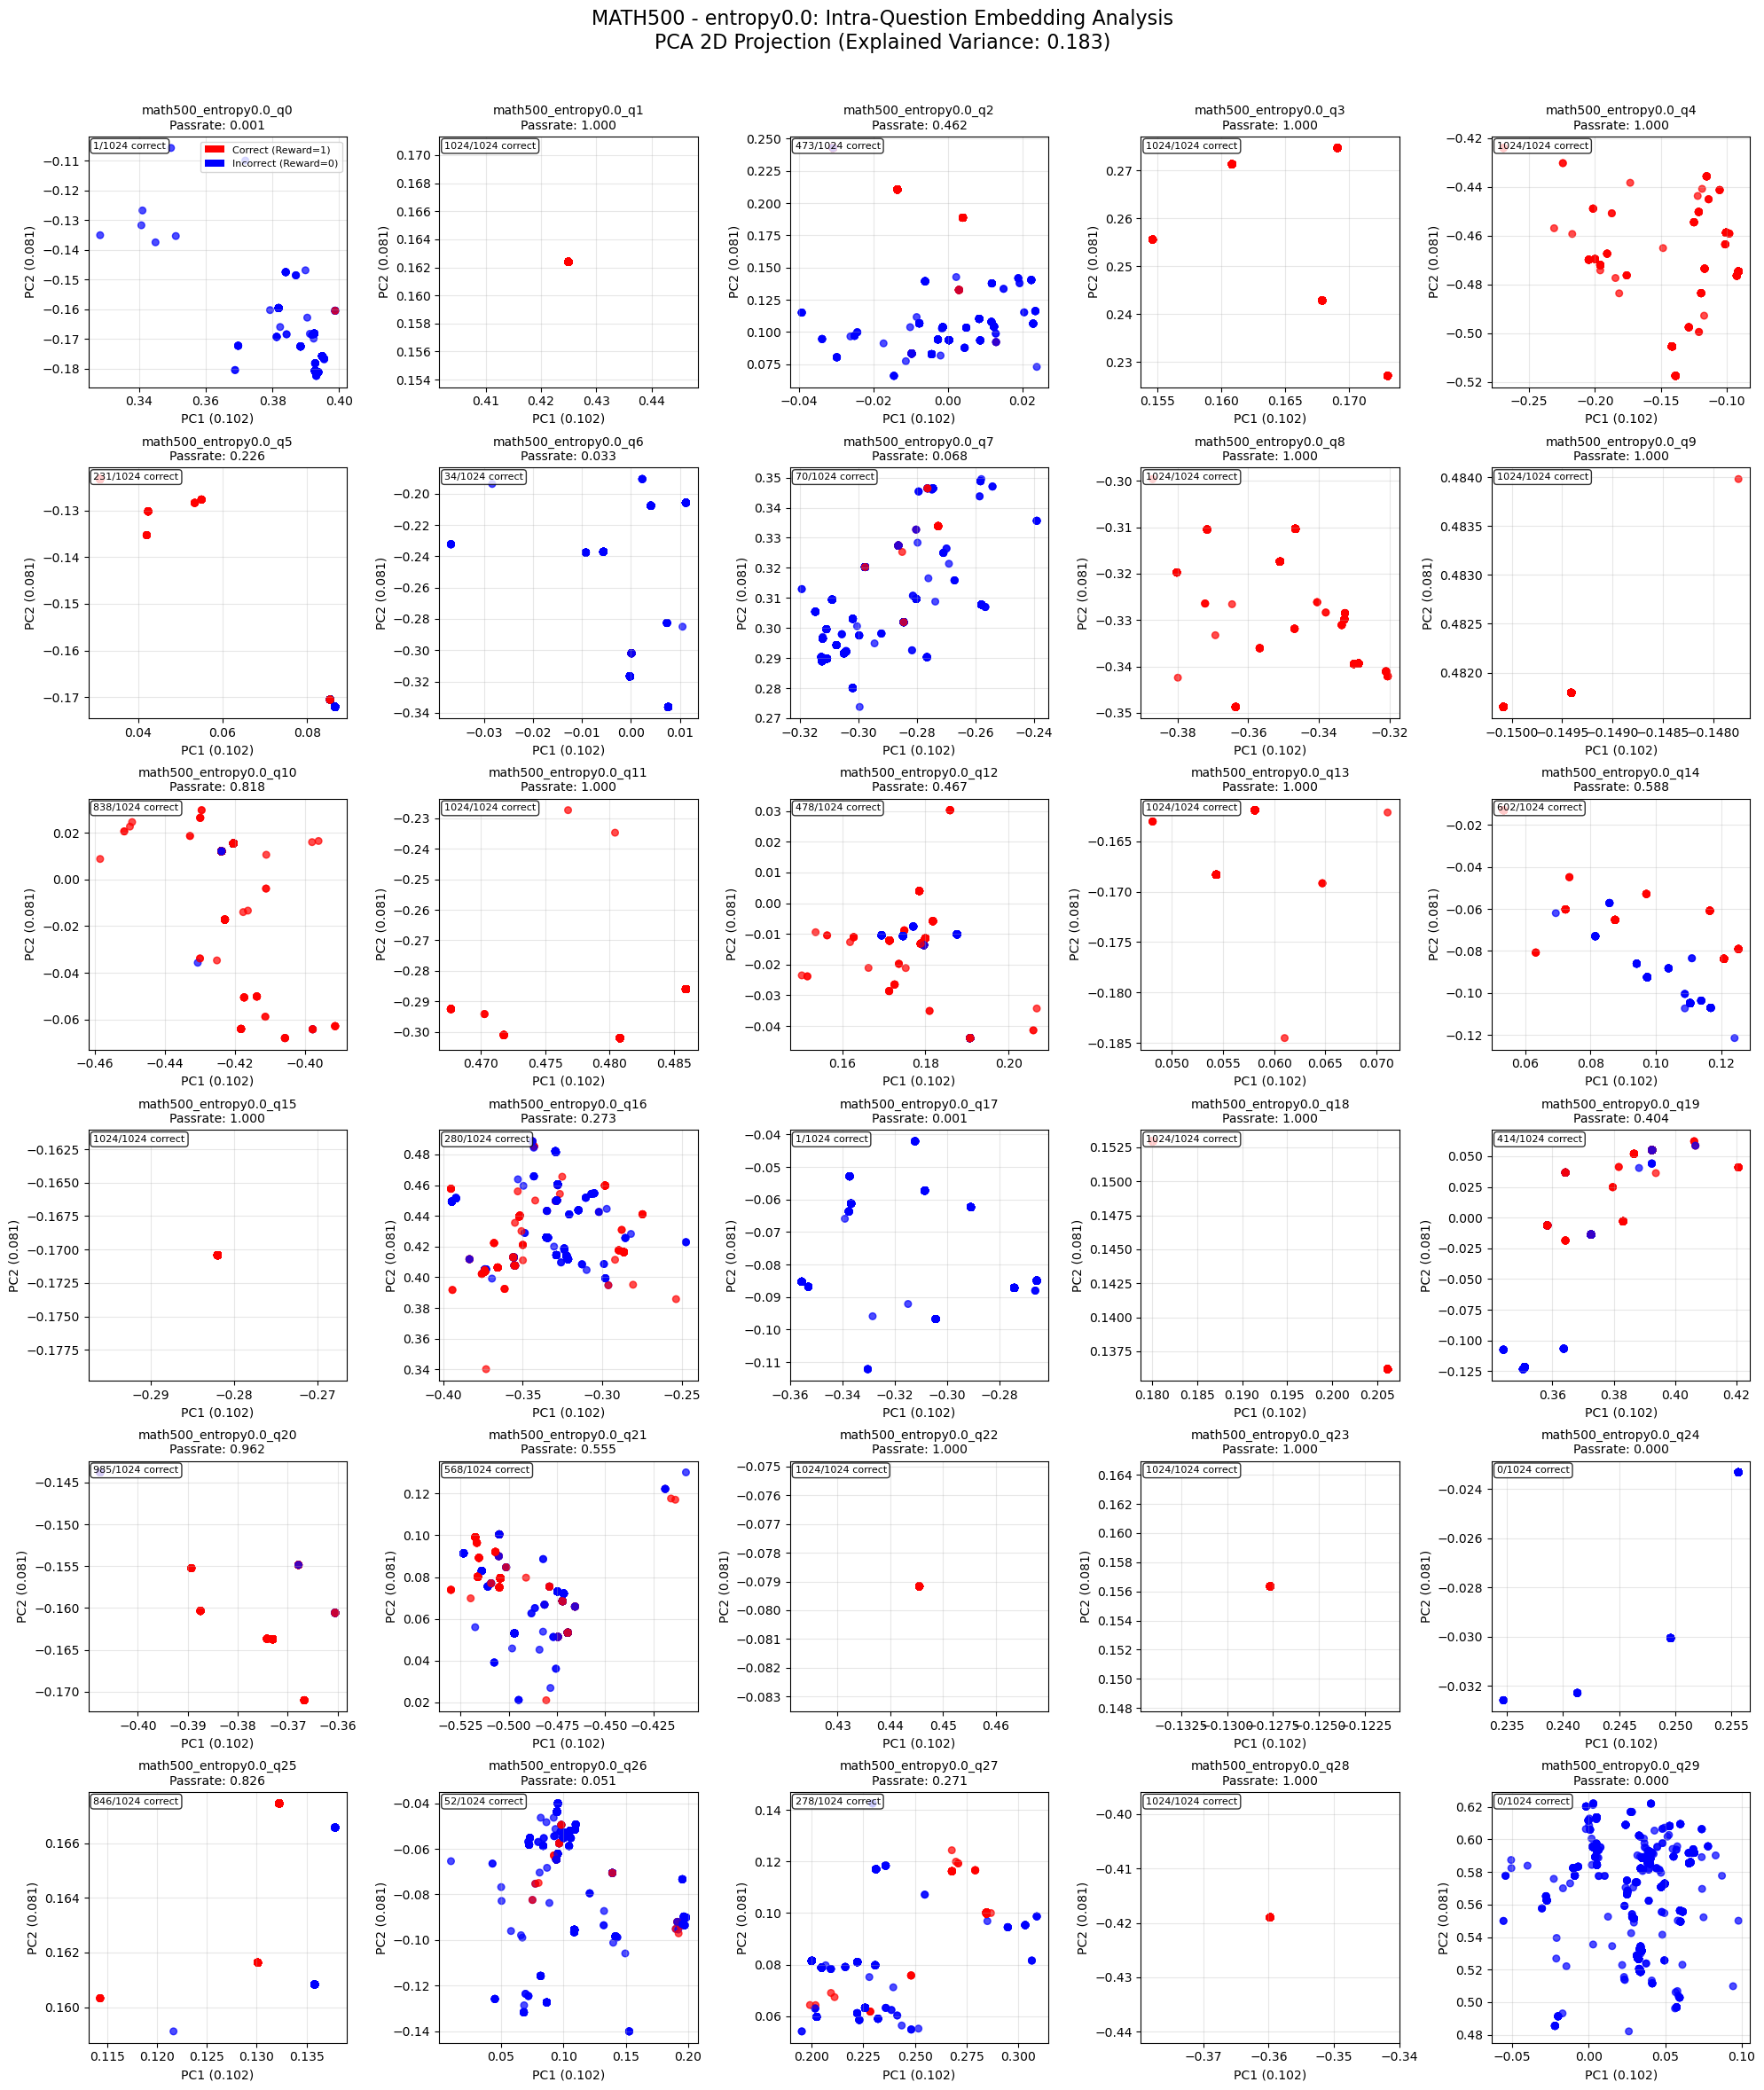

In [10]:
plot_pca('math500', 'entropy0.0')

## Sentence-Level Embedding Analysis

Now we'll split each answer into sentences and embed each sentence separately to analyze the structure of responses at a more granular level.

In [11]:
import re
import nltk
from nltk.tokenize import sent_tokenize

In [12]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /u/rfechner/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [19]:
RECOMPUTE=True

In [20]:
N_RESPONSES = 100
def split_into_sentences(text):
    """Split text into sentences using NLTK or simple regex."""
    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if s.strip() and len(s.strip()) > 3]

    return sentences

def create_sentence_embeddings_dataset(embedding_df):
    """Create sentence-level embeddings for all responses."""
    sentence_data = []
    print(f"Processing {len(embedding_df)} responses for sentence-level analysis...")
    
    # current embeddings dataframe has num_questoins x num_responses rows. In this case, its 30k.
    # We have to select a sub-set of N_RESPONSES per question. For this, we group the dataset by question_id first.
    groups = embedding_df.groupby('question_idx')
    subset = groups.apply(lambda x: x.sample(n=min(N_RESPONSES, len(x)), random_state=42)).reset_index(drop=True)

    for idx, row in subset.iterrows():
        response = str(row['response'])
        sentences = split_into_sentences(response)
        
        for sent_idx, sentence in enumerate(sentences):
            sentence_data.append({
                'dataset': row['dataset'],
                'variant': row['variant'],
                'question_id': row['question_id'],
                'response_id': row['response_id'],
                'sentence_id': f"{row['response_id']}_s{sent_idx}",
                'sentence_idx': sent_idx,
                'sentence': sentence,
                'original_response': response,
                'reward': row['reward'],
                'passrate': row['passrate'],
                'is_correct': row['is_correct'],
                'prompt': row['prompt']
            })
    
    sentence_df = pd.DataFrame(sentence_data)
    print(f"Created {len(sentence_df)} sentence embeddings from {len(embedding_df)} responses")
    print(f"Average sentences per response: {len(sentence_df) / len(embedding_df):.1f}")
    
    return sentence_df

def compute_sentence_embeddings(sentence_df):
    """Compute embeddings for all sentences."""
    texts = sentence_df['sentence'].tolist()
    model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')
    sentence_embeddings = model.encode(texts, batch_size=512, show_progress_bar=True)
    
    print(f"Sentence embeddings shape: {sentence_embeddings.shape}")
    return sentence_embeddings

# Process sentence-level embeddings for math500 base
dataset_focus = 'math500'
variant_focus = 'entropy0.01'

if (dataset_focus in final_embeddings and 
    variant_focus in final_embeddings[dataset_focus]):
    
    if RECOMPUTE:
        # Get the original embedding data
        embedding_df = final_embeddings[dataset_focus][variant_focus]['embedding_df']
        
        # Create sentence-level dataset
        sentence_df = create_sentence_embeddings_dataset(embedding_df)

        # Compute sentence embeddings
        sentence_embeddings = compute_sentence_embeddings(sentence_df)
        
        pkl = {
            'sentence_df' : sentence_df,
            'sentence_embeddings' : sentence_embeddings,
        }

        print('Dumping embeddings...')
        with open(f'embeddings_data/{dataset_focus}_{variant_focus}_sentence_embeddings.pkl', 'wb') as file:
            pickle.dump(pkl, file)

        print(f"\nSentence-level analysis ready for {dataset_focus} - {variant_focus}")
        print(f"Sentences: {len(sentence_df)}")
    else:
        print('RECOMPUTE=False, loading from disk!')
        with open(f'embeddings_data/{dataset_focus}_{variant_focus}_sentence_embeddings.pkl', 'rb') as file:
            tmp = pickle.load(file)
            sentence_df, sentence_embeddings = tmp['sentence_df'], tmp['sentence_embeddings']
            del tmp
            
else:
    print(f"No data available for {dataset_focus} - {variant_focus}")

Processing 30720 responses for sentence-level analysis...


Created 31507 sentence embeddings from 30720 responses
Average sentences per response: 1.0


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Sentence embeddings shape: (31507, 384)
Dumping embeddings...

Sentence-level analysis ready for math500 - entropy0.01
Sentences: 31507


Sentence PCA explained variance: 0.494


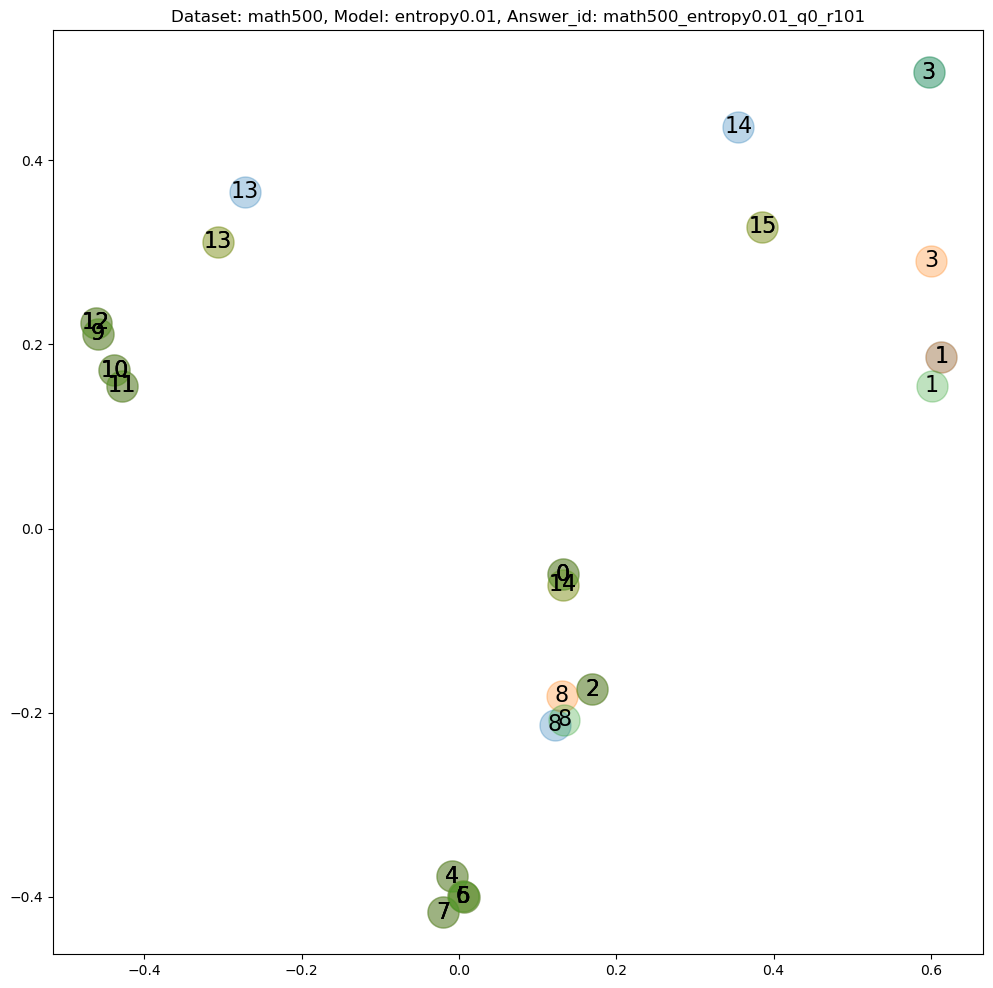

In [22]:
import matplotlib
## Single Question Sentence-Level PCA Analysis
NUM_ANSWERS = 3
colors = matplotlib.cm.tab10(range(NUM_ANSWERS))

# Let's analyze a single question at the sentence level
if 'sentence_df' in locals() and 'sentence_embeddings' in locals():
    # Get the first NUM_ANSWERS answers for detailed analysis
    unique_answer_ids = np.unique(sentence_df['response_id'])
    answer_ids = unique_answer_ids[:NUM_ANSWERS]
    answers_sentences = sentence_df[sentence_df['response_id'].isin(answer_ids)].copy()
    
    # Get embeddings for this question
    mask = sentence_df['response_id'].isin(answer_ids)
    answers_sentence_embeddings = sentence_embeddings[mask]
    
    # Apply PCA to sentence embeddings
    from sklearn.decomposition import PCA
    pca_sentences = PCA(n_components=2, random_state=42)
    sentence_embeddings_2d = pca_sentences.fit_transform(answers_sentence_embeddings)
    
    print(f"Sentence PCA explained variance: {pca_sentences.explained_variance_ratio_.sum():.3f}")
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 12))
    for i, answer_id in enumerate(answer_ids):

        # plot each answer sentence-wise on its own first. Use as scatter points with the 
        # numbers of the index of the sentence within the response in it.
        cur_mask = answers_sentences['response_id'] == answer_id
        pca_embs = sentence_embeddings_2d[cur_mask]
        ax.scatter(pca_embs[:, 0], pca_embs[:, 1], s=500, alpha=0.3, c=colors[i])

        # annotate with sentence index
        for i in range(len(pca_embs)):
            ax.annotate(i, pca_embs[i], ha='center', va='center', fontsize=16)
        ax.set_title(f'Dataset: {dataset_focus}, Model: {variant_focus}, Answer_id: {answer_id}')

    plt.show()
else:
    print("Sentence-level data not available. Run the previous cell first.")

In [15]:
"""
    Further Ideas:
        - look at euclidean distances of first few sentences of base and entropy models
        - matching algorithm?
        - 
"""

'\n    Further Ideas:\n        - look at euclidean distances of first few sentences of base and entropy models\n        - matching algorithm?\n        - \n'